In [1]:
import pandas as pd

df = pd.read_csv("../data/Womens Clothing E-Commerce Reviews.csv")

print(df.shape)
df.head()

(23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [2]:
department_summary = (
    df.groupby("Department Name")
    .agg(
        Average_Rating=("Rating", "mean"),
        Share_Recommended=("Recommended IND", "mean")
    )
    .reset_index()
)

department_summary["Share_Recommended"] = (
    department_summary["Share_Recommended"] * 100
)

department_summary

,Department Name,Average_Rating,Share_Recommended
0,Bottoms,4.288760,85.127665
1,Dresses,4.150815,80.819750
2,Intimate,4.280115,85.014409
3,Jackets,4.264535,83.624031
4,Tops,4.172239,81.515094
5,Trend,3.815126,73.949580


In [3]:
class_summary = (
    df.groupby("Class Name")
    .agg(
        Average_Rating=("Rating", "mean"),
        Share_Recommended=("Recommended IND", "mean")
    )
    .reset_index()
)

class_summary["Share_Recommended"] = (
    class_summary["Share_Recommended"] * 100
)

class_summary

,Class Name,Average_Rating,Share_Recommended
0,Blouses,4.154020,81.013884
1,Casual bottoms,4.500000,100.000000
2,Chemises,4.000000,100.000000
3,Dresses,4.150815,80.819750
4,Fine gauge,4.260909,83.727273
5,Intimates,4.279221,85.714286
6,Jackets,4.295455,84.517045
7,Jeans,4.360942,88.142982
8,Knits,4.161677,81.767499
9,Layering,4.376712,88.356164


In [4]:
low_rating_by_class = (
    df[df["Rating"].isin([1, 2])]
    .groupby("Class Name")
    .size()
    .reset_index(name="Low_Rating_Count")
    .sort_values("Low_Rating_Count", ascending=False)
)

low_rating_by_class

,Class Name,Low_Rating_Count
1,Dresses,689
6,Knits,506
0,Blouses,348
15,Sweaters,155
11,Pants,124
2,Fine gauge,105
5,Jeans,85
13,Skirts,85
4,Jackets,73
9,Lounge,48


In [5]:
age_band_summary = (
    df.groupby(pd.cut(
        df["Age"],
        bins=[0, 20, 30, 40, 50, 60, 100],
        labels=["≤20", "21–30", "31–40", "41–50", "51–60", "61+"]
    ))
    .agg(
        Average_Rating=("Rating", "mean"),
        Review_Count=("Rating", "count")
    )
    .reset_index()
)

age_band_summary

C:\Users\Admin\AppData\Local\Temp\ipykernel_15016\3977258424.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(


,Age,Average_Rating,Review_Count
0,≤20,4.322368,152
1,21–30,4.186127,3186
2,31–40,4.166835,7912
3,41–50,4.166723,5908
4,51–60,4.245952,3891
5,61+,4.287238,2437


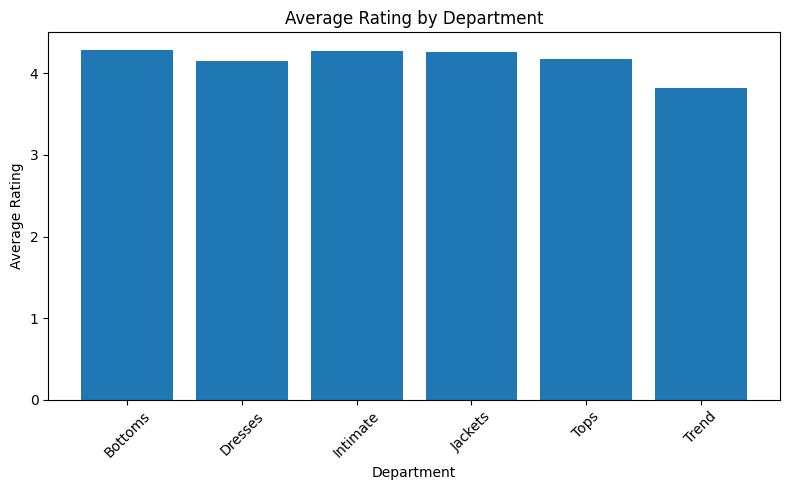

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    department_summary["Department Name"],
    department_summary["Average_Rating"]
)

plt.xlabel("Department")
plt.ylabel("Average Rating")
plt.title("Average Rating by Department")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

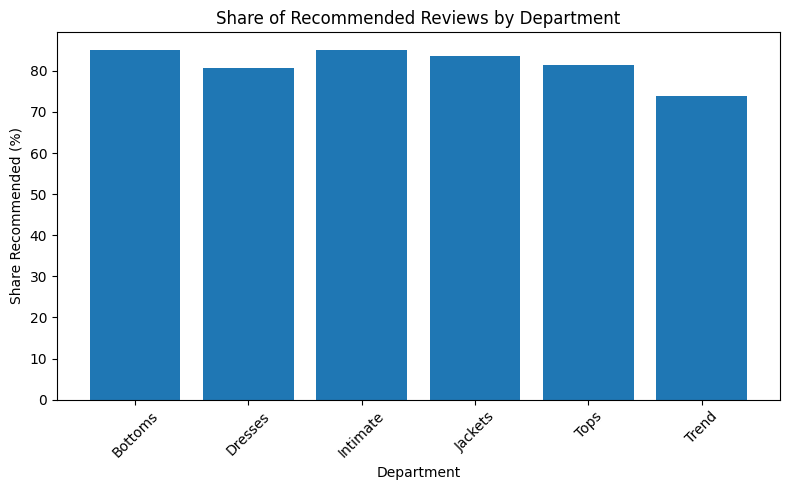

In [7]:
plt.figure(figsize=(8, 5))

plt.bar(
    department_summary["Department Name"],
    department_summary["Share_Recommended"]
)

plt.xlabel("Department")
plt.ylabel("Share Recommended (%)")
plt.title("Share of Recommended Reviews by Department")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

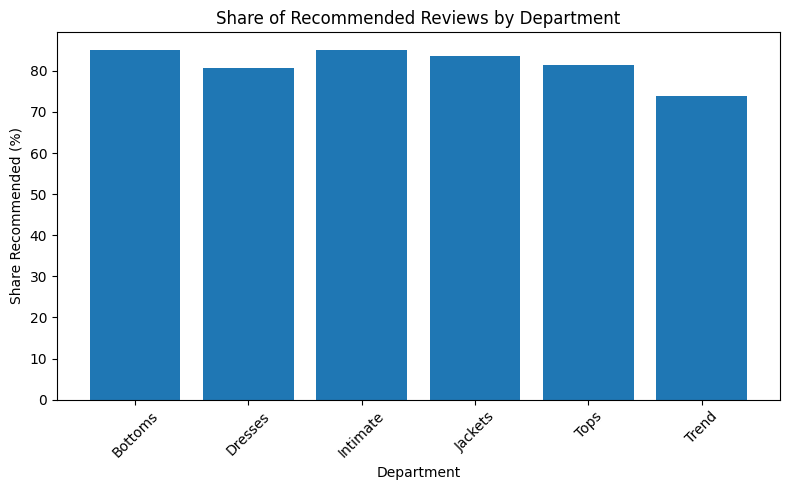

In [8]:
plt.figure(figsize=(8, 5))

plt.bar(
    department_summary["Department Name"],
    department_summary["Share_Recommended"]
)

plt.xlabel("Department")
plt.ylabel("Share Recommended (%)")
plt.title("Share of Recommended Reviews by Department")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

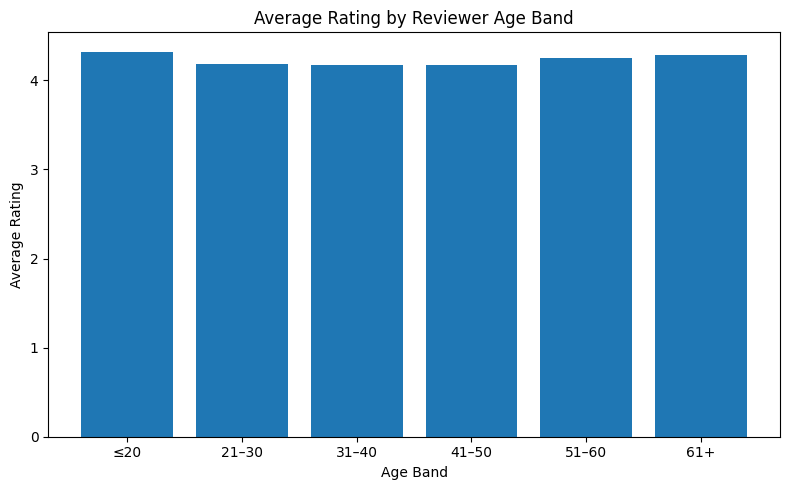

In [9]:
plt.figure(figsize=(8, 5))

plt.bar(
    age_band_summary["Age"].astype(str),
    age_band_summary["Average_Rating"]
)

plt.xlabel("Age Band")
plt.ylabel("Average Rating")
plt.title("Average Rating by Reviewer Age Band")

plt.tight_layout()
plt.show()

In [10]:
print("PART B SUMMARY")
print("\nDepartment Summary:")
print(department_summary)

print("\nClasses with Most 1–2 Star Reviews:")
print(low_rating_by_class)

print("\nRating by Age Band:")
print(age_band_summary)

PART B SUMMARY

Department Summary:
  Department Name  Average_Rating  Share_Recommended
0         Bottoms        4.288760          85.127665
1         Dresses        4.150815          80.819750
2        Intimate        4.280115          85.014409
3         Jackets        4.264535          83.624031
4            Tops        4.172239          81.515094
5           Trend        3.815126          73.949580

Classes with Most 1–2 Star Reviews:
    Class Name  Low_Rating_Count
1      Dresses               689
6        Knits               506
0      Blouses               348
15    Sweaters               155
11       Pants               124
2   Fine gauge               105
5        Jeans                85
13      Skirts                85
4      Jackets                73
9       Lounge                48
16        Swim                38
10   Outerwear                36
12      Shorts                26
14       Sleep                25
17       Trend                22
8      Legwear              

In [12]:
department_summary.to_csv(
    "../outputs/department_summary.csv",
    index=False
)

class_summary.to_csv(
    "../outputs/class_summary.csv",
    index=False
)

low_rating_counts.to_csv(
    "../outputs/low_rating_counts_by_class.csv",
    index=False
)

age_summary.to_csv(
    "../outputs/age_band_summary.csv",
    index=False
)

print("Part B outputs saved successfully!")

NameError: name 'low_rating_counts' is not defined

In [13]:
print([name for name in globals() if "low" in name.lower()])

['low_rating_by_class']


In [16]:
department_summary.to_csv(
    "../outputs/department_summary.csv",
    index=False
)

class_summary.to_csv(
    "../outputs/class_summary.csv",
    index=False
)

low_rating_by_class.to_csv(
    "../outputs/low_rating_counts_by_class.csv",
    index=False
)

age_band_summary.to_csv(
    "../outputs/age_band_summary.csv",
    index=False
)

print("Part B outputs saved successfully!")

Part B outputs saved successfully!


In [15]:
print([name for name in globals() if "age" in name.lower()])

['__package__', 'age_band_summary']
